# Model Evaluation

This notebook directly loads the pre-trained checkpoints for STGCN, GCNLSTM, and DCRNN models and runs their respective evaluation loops symmetrically with masking for fair comparison.

### 1. Library Imports and Setup

In [33]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import time
import pandas as pd

# Add custom modules
from utils.data_loader import get_dataloaders, load_adjacency_matrix
from models.STGCN import STGCN_Model
from models.GCNLSTM import GCNLSTM
from models.baseline import NaiveBaseline
from models.DCRNN import DCRNNModel  

# Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")

Executing on: cuda


### 2. Hyperparameters & Data Loading

In [ ]:
# Evaluation & Global Settings
RETRAIN_STGCN = False   # Set True to force retraining STGCN even if checkpoint exists.
RETRAIN_GCNLSTM = False # Set True to force retraining GCN-LSTM even if checkpoint exists.
RETRAIN_DCRNN = False   # Set True to force retraining DCRNN even if checkpoint exists.

BATCH_SIZE = 32
NUM_NODES = 150
IN_FEATURES = 1
HISTORICAL_STEPS = 12
PRED_STEPS = 3
EVAL_MASK_THRESHOLD = 10.0 # Ignore volumes < 10

# Load Adjacency Matrix
adj_matrix = load_adjacency_matrix('data/adj_mat_volume.pkl').to(device)
print(f"Loaded Adjacency Matrix: {adj_matrix.shape}")

# Build uniformly named row-normalized adjacency matrix for all graph-conv models
norm_adj_matrix = adj_matrix.clone()
idx = torch.arange(norm_adj_matrix.size(0), device=norm_adj_matrix.device)
norm_adj_matrix[idx, idx] = 1.0
degree = norm_adj_matrix.sum(dim=1, keepdim=True)
degree = torch.where(degree == 0, torch.ones_like(degree), degree)
norm_adj_matrix = norm_adj_matrix / degree

# Load STGCN-formatted DataLoaders (Can be reshaped dynamically for other models below)
train_loader, val_loader, test_loader, data_mean, data_std = get_dataloaders(
    csv_path='data/sensor_volume_150.csv', 
    seq_len=HISTORICAL_STEPS, 
    pre_len=PRED_STEPS, 
    batch_size=BATCH_SIZE
)
print("Testing Flow & DataLoaders initialized (Train, Val, Test).")

Loaded Adjacency Matrix: torch.Size([150, 150])


Testing Flow & DataLoaders initialized (Train, Val, Test).


### 3. Unified Training & Initialization Pipeline
If a checkpoint exists and the model-specific retrain flag is `False` (`RETRAIN_STGCN`, `RETRAIN_GCNLSTM`, `RETRAIN_DCRNN`), that model will skip training and load weights. If shape dimensions mismatch (from older tests), it will force retrain automatically.

In [ ]:
gcn_lstm_ckpt_scaler_mean = None
gcn_lstm_ckpt_scaler_std = None

def train_model(model, train_loader, val_loader, save_path, format_type='stgcn', 
                epochs=50, lr=0.005, weight_decay=1e-4, patience=10, retrain=False):
    global gcn_lstm_ckpt_scaler_mean, gcn_lstm_ckpt_scaler_std

    # Fast-Track: Load existing model explicitly if NOT retraining
    if os.path.exists(save_path) and not retrain:
        try:
            ckpt = torch.load(save_path, map_location=device)
            # Accommodate dictionary checkpoints (like from older gcn_lstm saves)
            state_dict = ckpt['model_state_dict'] if 'model_state_dict' in ckpt else ckpt
            model.load_state_dict(state_dict)

            # If this is a lstm.py-style checkpoint, keep per-node scaler for evaluation compatibility
            if format_type == 'gcnlstm' and isinstance(ckpt, dict):
                if 'scaler_mean' in ckpt and 'scaler_std' in ckpt:
                    gcn_lstm_ckpt_scaler_mean = torch.as_tensor(ckpt['scaler_mean'], dtype=torch.float32, device=device)
                    gcn_lstm_ckpt_scaler_std = torch.as_tensor(ckpt['scaler_std'], dtype=torch.float32, device=device)
                    gcn_lstm_ckpt_scaler_std = torch.where(
                        gcn_lstm_ckpt_scaler_std == 0,
                        torch.ones_like(gcn_lstm_ckpt_scaler_std),
                        gcn_lstm_ckpt_scaler_std
                    )
                    print("[GCNLSTM] Loaded per-node scaler from checkpoint.")

            print(f"[{format_type.upper()}] Loaded checkpoint from '{save_path}'. Skipping training.")
            return model
        except Exception as e:
            print(f"[{format_type.upper()}] Failed to load checkpoint (maybe shape mismatch): {e}.")
            print("Forcing retrain...")
            
    print(f"\n--- Training [{format_type.upper()}] model for up to {epochs} epochs ---")

    # Retraining in unified pipeline uses notebook global scaling; clear external scaler compatibility path
    if format_type == 'gcnlstm':
        gcn_lstm_ckpt_scaler_mean = None
        gcn_lstm_ckpt_scaler_std = None

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)
    criterion = torch.nn.MSELoss()
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = model.state_dict().copy()
    
    for epoch in range(epochs):
        start_time = time.time()
        
        # ========== TRAIN PHASE ==========
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            
            # Architecture-specific Reshapes and FWD passes
            if format_type == 'stgcn':
                preds = model(batch_X, norm_adj_matrix)
            elif format_type == 'gcnlstm':
                batch_X = batch_X.squeeze(1).transpose(1, 2)
                preds = model(batch_X, norm_adj_matrix)
                preds = preds.transpose(1, 2)
            elif format_type == 'dcrnn':
                batch_X = batch_X.permute(0, 3, 2, 1)
                preds = model(batch_X, T_f=norm_adj_matrix, T_b=norm_adj_matrix.T)
                preds = preds.squeeze(-1).transpose(1, 2)
                
            loss = criterion(preds, batch_y)
            loss.backward()
            
            # RNNs typically need gradient clipping to prevent explosion
            if format_type in ['gcnlstm', 'dcrnn']:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                
            optimizer.step()
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
        
        # ========== VALIDATION PHASE ==========
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                
                # Architecture-specific Reshapes
                if format_type == 'stgcn':
                    preds = model(batch_X, norm_adj_matrix)
                elif format_type == 'gcnlstm':
                    batch_X = batch_X.squeeze(1).transpose(1, 2)
                    preds = model(batch_X, norm_adj_matrix)
                    preds = preds.transpose(1, 2)
                elif format_type == 'dcrnn':
                    batch_X = batch_X.permute(0, 3, 2, 1)
                    preds = model(batch_X, T_f=norm_adj_matrix, T_b=norm_adj_matrix.T)
                    preds = preds.squeeze(-1).transpose(1, 2)
                    
                loss = criterion(preds, batch_y)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)
        
        # Early Stopping & Checkpoint Logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_state = model.state_dict().copy()
        else:
            patience_counter += 1
            
        epoch_time = time.time() - start_time
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:2d}/{epochs}] | Time: {epoch_time:.1f}s | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
            
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
            
    print(f"[{format_type.upper()}] Training complete! Best Validation Loss: {best_val_loss:.4f}")
    model.load_state_dict(best_state)
    torch.save(model.state_dict(), save_path)
    return model

# -------------------------------------------------------------
# 1. BASELINE SETUP
# -------------------------------------------------------------
baseline_model = NaiveBaseline(pred_steps=PRED_STEPS).to(device)
print("[BASELINE] Model initialized (No training required).")

# -------------------------------------------------------------
# 2. STGCN SETUP & TRAIN
# -------------------------------------------------------------
stgcn_model = STGCN_Model(
    num_nodes=NUM_NODES,
    in_features=IN_FEATURES,
    historical_steps=HISTORICAL_STEPS,
    pred_steps=PRED_STEPS
).to(device)

stgcn_model = train_model(
    stgcn_model, train_loader, val_loader, 
    save_path='best_stgcn.pt', format_type='stgcn',
    epochs=50, lr=0.005, weight_decay=1e-4, patience=10,
    retrain=RETRAIN_STGCN
)
stgcn_model.eval()

# -------------------------------------------------------------
# 3. GCN-LSTM SETUP & TRAIN
# -------------------------------------------------------------
# NOTE: Output length unified to PRED_STEPS (3) here for comparative forecasting!
# If your old checkpoint was outputting 12, it will error parsing and retrain cleanly.
gcn_lstm_model = GCNLSTM(
    num_nodes=NUM_NODES, 
    in_features=IN_FEATURES, 
    gcn_hidden=32,
    lstm_hidden=64, 
    output_len=PRED_STEPS 
).to(device)

gcn_lstm_model = train_model(
    gcn_lstm_model, train_loader, val_loader, 
    save_path='gcn_lstm_checkpoint.pth', format_type='gcnlstm',
    epochs=100, lr=1e-3, weight_decay=1e-4, patience=15,
    retrain=RETRAIN_GCNLSTM
)
gcn_lstm_model.eval()

# -------------------------------------------------------------
# 4. DCRNN SETUP & TRAIN
# -------------------------------------------------------------
dcrnn_model = DCRNNModel(
    num_nodes=NUM_NODES,
    in_features=IN_FEATURES,
    hidden_dim=64,
    out_features=1,
    output_seq_len=PRED_STEPS,
    num_layers=2,
    K=2,
    use_attention=False
).to(device)

dcrnn_model = train_model(
    dcrnn_model, train_loader, val_loader, 
    save_path='dcrnn_checkpoint.pth', format_type='dcrnn',
    epochs=50, lr=0.001, weight_decay=0.0, patience=10,
    retrain=RETRAIN_DCRNN
)
dcrnn_model.eval()

[BASELINE] Model initialized (No training required).
[STGCN] Loaded checkpoint from 'best_stgcn.pt'. Skipping training.
[GCNLSTM] Loaded per-node scaler from checkpoint.
[GCNLSTM] Loaded checkpoint from 'gcn_lstm_checkpoint.pth'. Skipping training.
[DCRNN] Loaded checkpoint from 'dcrnn_checkpoint.pth'. Skipping training.


C:\Users\hataj\AppData\Local\Temp\ipykernel_20816\3380883101.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(save_path, map_location=device)


DCRNNModel(
  (learned_adj): LearnedAdjacency()
  (encoder): DCGRUEncoder(
    (cells): ModuleList(
      (0): DCGRUCell(
        (gate_conv): DiffusionConv(
          (linear): Linear(in_features=325, out_features=128, bias=True)
        )
        (cand_conv): DiffusionConv(
          (linear): Linear(in_features=325, out_features=64, bias=True)
        )
        (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      )
      (1): DCGRUCell(
        (gate_conv): DiffusionConv(
          (linear): Linear(in_features=640, out_features=128, bias=True)
        )
        (cand_conv): DiffusionConv(
          (linear): Linear(in_features=640, out_features=64, bias=True)
        )
        (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (decoder): DCGRUDecoder(
    (cells): ModuleList(
      (0): DCGRUCell(
        (gate_conv): DiffusionConv(
          (linear): Linear(in_features=325, out_features=128, bias=True)
        )
        (cand_conv): Diff

### 4. Shared Evaluation Pipeline
We define a helper function to evaluate any model given its respective spatial-temporal tensor reshaping requirements.

In [ ]:
def evaluate_model(model, loader, name, format_type='stgcn', pred_slice=3):
    """
    Evaluates a given model based on the unified test_loader structure.
    format_type: 
        'stgcn': expects (Batch, Channels, Nodes, Time)
        'gcnlstm': expects (Batch, Time, Nodes)
        'dcrnn': expects (Batch, Time, Nodes, Channels)
    """
    all_preds = []
    all_targets = []
    gcn_uses_ckpt_scaler = (
        format_type == 'gcnlstm'
        and gcn_lstm_ckpt_scaler_mean is not None
        and gcn_lstm_ckpt_scaler_std is not None
    )
    
    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            if format_type == 'stgcn':
                preds = model(batch_X, norm_adj_matrix)
                all_preds.append(preds.cpu().numpy())
                all_targets.append(batch_y.cpu().numpy())
                
            elif format_type == 'gcnlstm':
                if gcn_uses_ckpt_scaler:
                    # Convert notebook-normalized inputs back to raw, then to checkpoint per-node normalization.
                    batch_X_raw = batch_X * data_std + data_mean
                    mean_x = gcn_lstm_ckpt_scaler_mean.view(1, 1, NUM_NODES, 1)
                    std_x = gcn_lstm_ckpt_scaler_std.view(1, 1, NUM_NODES, 1)
                    batch_X_model = (batch_X_raw - mean_x) / std_x

                    # Forward in lstm.py normalization space.
                    batch_X_model = batch_X_model.squeeze(1).transpose(1, 2)
                    preds = model(batch_X_model, norm_adj_matrix)  # (B, T, N)

                    # Denormalize predictions with checkpoint scaler to raw traffic volume.
                    preds_raw = preds * gcn_lstm_ckpt_scaler_std.view(1, 1, NUM_NODES) + gcn_lstm_ckpt_scaler_mean.view(1, 1, NUM_NODES)

                    # Targets to raw as well for fair metric comparison.
                    targets_raw = batch_y * data_std + data_mean  # (B, N, T)

                    # Keep shared layout as (B, N, T)
                    all_preds.append(preds_raw.transpose(1, 2).cpu().numpy())
                    all_targets.append(targets_raw.cpu().numpy())
                else:
                    batch_X = batch_X.squeeze(1).transpose(1, 2)
                    preds = model(batch_X, norm_adj_matrix)
                    all_preds.append(preds.cpu().numpy())
                    all_targets.append(batch_y.cpu().numpy())
                
            elif format_type == 'dcrnn':
                # STGCN format to DCRNN format: 
                # (Batch, Channels=1, Nodes, Time) -> (Batch, Time, Nodes, Channels)
                batch_X = batch_X.permute(0, 3, 2, 1)
                
                # DCRNN requires forward and backward transition matrices 
                # For simplicity here we just pass the adjacency metric twice (or use graph_utils later)
                preds = model(batch_X, T_f=norm_adj_matrix, T_b=norm_adj_matrix.T)
                
                # Squeeze the channel dimension out of the DCRNN output (Batch, Time, Nodes, 1) -> (Batch, Nodes, Time)
                preds = preds.squeeze(-1).transpose(1, 2)
                all_preds.append(preds.cpu().numpy())
                all_targets.append(batch_y.cpu().numpy())

    # Concatenate results
    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    # Align orientation if model output is (B, T, N) but targets are (B, N, T)
    if all_preds.shape != all_targets.shape:
        if (
            all_preds.ndim == 3
            and all_targets.ndim == 3
            and all_preds.shape[1] == all_targets.shape[2]
            and all_preds.shape[2] == all_targets.shape[1]
        ):
            all_preds = np.transpose(all_preds, (0, 2, 1))
    
    # If data is already in raw space (lstm.py checkpoint compatibility path), skip notebook un-normalization.
    if gcn_uses_ckpt_scaler:
        preds_unnorm = all_preds
        targets_unnorm = all_targets
    else:
        if all_preds.shape[-1] > pred_slice:
            all_preds = all_preds[..., :pred_slice]

        # Un-normalize
        preds_unnorm = (all_preds * data_std) + data_mean
        targets_unnorm = (all_targets * data_std) + data_mean

    # Apply Masking
    mask = targets_unnorm > EVAL_MASK_THRESHOLD
    if not np.any(mask):
        print("-" * 40)
        print(f"{name} Results")
        print(f"No target values above mask threshold ({EVAL_MASK_THRESHOLD}).")
        print("-" * 40)
        return preds_unnorm, targets_unnorm

    mae = np.mean(np.abs(preds_unnorm[mask] - targets_unnorm[mask]))
    rmse = np.sqrt(np.mean(np.square(preds_unnorm[mask] - targets_unnorm[mask])))

    print("-" * 40)
    print(f"{name} Results")
    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print("-" * 40)
    
    return preds_unnorm, targets_unnorm

### 5. Running Evaluations

In [30]:
# Evaluate Baseline
base_preds, trues = evaluate_model(baseline_model, test_loader, "Naive Baseline", format_type='stgcn')

# Evaluate STGCN
stgcn_preds, _ = evaluate_model(stgcn_model, test_loader, "STGCN Model", format_type='stgcn')

# Evaluate GCN-LSTM
lstm_preds, _ = evaluate_model(gcn_lstm_model, test_loader, "GCN-LSTM Model", format_type='gcnlstm')

# Evaluate DCRNN
dcrnn_preds, _ = evaluate_model(dcrnn_model, test_loader, "DCRNN Model", format_type='dcrnn')

----------------------------------------
Naive Baseline Results
MAE:  878.999
RMSE: 1328.162
----------------------------------------
----------------------------------------
STGCN Model Results
MAE:  464.356
RMSE: 706.686
----------------------------------------
----------------------------------------
GCN-LSTM Model Results
MAE:  499.531
RMSE: 712.180
----------------------------------------
----------------------------------------
DCRNN Model Results
MAE:  264.736
RMSE: 397.835
----------------------------------------


### 6. Visualizing Forecasts
Compare the predicted values of all three architectures to the ground truth against a single sensor target over time.

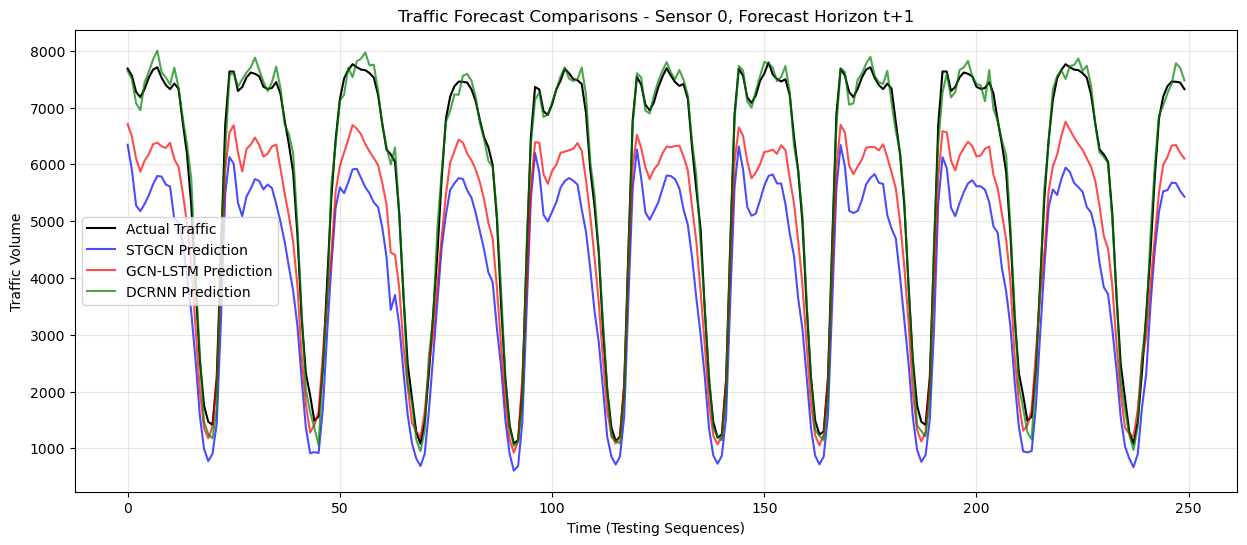

In [31]:
SENSOR = 0
TIMESTEP = 0 
PLT_LEN = 250

plt.figure(figsize=(15, 6))

plt.plot(trues[:PLT_LEN, SENSOR, TIMESTEP], label='Actual Traffic', color='black', linewidth=1.5)
# plt.plot(base_preds[:PLT_LEN, SENSOR, TIMESTEP], label='Baseline', color='gray', linestyle=':')
plt.plot(stgcn_preds[:PLT_LEN, SENSOR, TIMESTEP], label='STGCN Prediction', color='blue', alpha=0.7)
plt.plot(lstm_preds[:PLT_LEN, SENSOR, TIMESTEP], label='GCN-LSTM Prediction', color='red', alpha=0.7)
plt.plot(dcrnn_preds[:PLT_LEN, SENSOR, TIMESTEP], label='DCRNN Prediction', color='green', alpha=0.7)

plt.title(f'Traffic Forecast Comparisons - Sensor {SENSOR}, Forecast Horizon t+{TIMESTEP+1}')
plt.xlabel('Time (Testing Sequences)')
plt.ylabel('Traffic Volume')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 7. Adjacency Ablation for STGCN and GCN-LSTM
This optional experiment retrains only STGCN and GCN-LSTM across multiple adjacency variants (`raw`, `row_norm`, `sym_norm`) and summarizes the masked MAE/RMSE results. DCRNN is intentionally excluded to keep runtime manageable.

In [ ]:
# -----------------------------
# Optional adjacency ablation
# -----------------------------
RUN_STGCN_ABLATION = True
RUN_GCNLSTM_ABLATION = True
ABLATION_RETRAIN = False  # First run will train if checkpoints do not exist.
GRAPH_MODES = ['raw', 'row_norm', 'sym_norm']

STGCN_ABLATION_EPOCHS = 50
GCNLSTM_ABLATION_EPOCHS = 100


def build_graph_variant(base_adj, mode):
    A = base_adj.clone()
    n = A.size(0)
    idx = torch.arange(n, device=A.device)

    if mode == 'raw':
        return A

    A[idx, idx] = 1.0
    degree = A.sum(dim=1, keepdim=True)
    degree = torch.where(degree == 0, torch.ones_like(degree), degree)

    if mode == 'row_norm':
        return A / degree

    if mode == 'sym_norm':
        deg_inv_sqrt = degree.pow(-0.5)
        deg_inv_sqrt = torch.where(torch.isinf(deg_inv_sqrt), torch.zeros_like(deg_inv_sqrt), deg_inv_sqrt)
        D_inv_sqrt = torch.diag(deg_inv_sqrt.squeeze())
        return D_inv_sqrt @ A @ D_inv_sqrt

    raise ValueError(f'Unknown graph mode: {mode}')


def compute_masked_metrics(preds_unnorm, targets_unnorm, threshold=10.0):
    mask = targets_unnorm > threshold
    if not np.any(mask):
        return np.nan, np.nan
    mae = np.mean(np.abs(preds_unnorm[mask] - targets_unnorm[mask]))
    rmse = np.sqrt(np.mean(np.square(preds_unnorm[mask] - targets_unnorm[mask])))
    return mae, rmse


ablation_results = []
_original_norm_adj = norm_adj_matrix.clone()
_original_gcn_mean = gcn_lstm_ckpt_scaler_mean
_original_gcn_std = gcn_lstm_ckpt_scaler_std

try:
    for graph_mode in GRAPH_MODES:
        graph_variant = build_graph_variant(adj_matrix, graph_mode)
        
        # Override the unified adjacency matrix for the ablation runs
        norm_adj_matrix = graph_variant

        if RUN_STGCN_ABLATION:
            stgcn_variant_model = STGCN_Model(
                num_nodes=NUM_NODES,
                in_features=IN_FEATURES,
                historical_steps=HISTORICAL_STEPS,
                pred_steps=PRED_STEPS
            ).to(device)

            stgcn_variant_model = train_model(
                stgcn_variant_model,
                train_loader,
                val_loader,
                save_path=f'ablation_stgcn_{graph_mode}.pt',
                format_type='stgcn',
                epochs=STGCN_ABLATION_EPOCHS,
                lr=0.005,
                weight_decay=1e-4,
                patience=10,
                retrain=ABLATION_RETRAIN
            )
            stgcn_variant_model.eval()

            preds, targets = evaluate_model(
                stgcn_variant_model,
                test_loader,
                f'STGCN ({graph_mode})',
                format_type='stgcn'
            )
            mae, rmse = compute_masked_metrics(preds, targets, EVAL_MASK_THRESHOLD)
            ablation_results.append({
                'model': 'STGCN',
                'graph_mode': graph_mode,
                'mae': mae,
                'rmse': rmse
            })

        if RUN_GCNLSTM_ABLATION:
            gcn_lstm_ckpt_scaler_mean = None
            gcn_lstm_ckpt_scaler_std = None

            gcn_variant_model = GCNLSTM(
                num_nodes=NUM_NODES,
                in_features=IN_FEATURES,
                gcn_hidden=32,
                lstm_hidden=64,
                output_len=PRED_STEPS
            ).to(device)

            gcn_variant_model = train_model(
                gcn_variant_model,
                train_loader,
                val_loader,
                save_path=f'ablation_gcnlstm_{graph_mode}.pth',
                format_type='gcnlstm',
                epochs=GCNLSTM_ABLATION_EPOCHS,
                lr=1e-3,
                weight_decay=1e-4,
                patience=15,
                retrain=ABLATION_RETRAIN
            )
            gcn_variant_model.eval()

            preds, targets = evaluate_model(
                gcn_variant_model,
                test_loader,
                f'GCN-LSTM ({graph_mode})',
                format_type='gcnlstm'
            )
            mae, rmse = compute_masked_metrics(preds, targets, EVAL_MASK_THRESHOLD)
            ablation_results.append({
                'model': 'GCN-LSTM',
                'graph_mode': graph_mode,
                'mae': mae,
                'rmse': rmse
            })
finally:
    norm_adj_matrix = _original_norm_adj
    gcn_lstm_ckpt_scaler_mean = _original_gcn_mean
    gcn_lstm_ckpt_scaler_std = _original_gcn_std

ablation_df = pd.DataFrame(ablation_results)
if not ablation_df.empty:
    ablation_df = ablation_df.sort_values(['model', 'rmse', 'mae']).reset_index(drop=True)
    display(ablation_df)
else:
    print('No ablation runs were enabled.')

C:\Users\hataj\AppData\Local\Temp\ipykernel_20816\3380883101.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(save_path, map_location=device)


[STGCN] Loaded checkpoint from 'ablation_stgcn_raw.pt'. Skipping training.
----------------------------------------
STGCN (raw) Results
MAE:  1428.298
RMSE: 1774.825
----------------------------------------

--- Training [GCNLSTM] model for up to 100 epochs ---


c:\Users\hataj\anaconda3\envs\ECEC147A\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [ 1/100] | Time: 11.1s | Train Loss: 0.9368 | Val Loss: 0.9297
Epoch [ 5/100] | Time: 12.4s | Train Loss: 0.9056 | Val Loss: 0.9385
Epoch [10/100] | Time: 12.0s | Train Loss: 0.9005 | Val Loss: 0.9371
Epoch [15/100] | Time: 11.5s | Train Loss: 0.8990 | Val Loss: 0.9312
Early stopping triggered at epoch 16
[GCNLSTM] Training complete! Best Validation Loss: 0.9297
----------------------------------------
GCN-LSTM (raw) Results
MAE:  1771.035
RMSE: 2110.196
----------------------------------------

--- Training [STGCN] model for up to 50 epochs ---
Epoch [ 1/50] | Time: 5.5s | Train Loss: 0.2257 | Val Loss: 0.1605
Epoch [ 5/50] | Time: 5.6s | Train Loss: 0.0944 | Val Loss: 0.1374
Epoch [10/50] | Time: 5.7s | Train Loss: 0.0866 | Val Loss: 0.1236
Epoch [15/50] | Time: 5.8s | Train Loss: 0.0824 | Val Loss: 0.1199
Epoch [20/50] | Time: 5.9s | Train Loss: 0.0826 | Val Loss: 0.1149
Epoch [25/50] | Time: 6.2s | Train Loss: 0.0775 | Val Loss: 0.1093
Epoch [30/50] | Time: 6.3s | Train Loss:

,model,graph_mode,mae,rmse
0,GCN-LSTM,row_norm,519.649109,740.794189
1,GCN-LSTM,sym_norm,702.080444,964.278992
2,GCN-LSTM,raw,1771.034668,2110.196289
3,STGCN,row_norm,472.019012,718.100830
4,STGCN,sym_norm,488.472290,727.838501
5,STGCN,raw,1428.297729,1774.824707
